<a href="https://colab.research.google.com/github/kulkarniraj2611/ai-debugging-assistant/blob/main/B1_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
# FACE DETECTION USING OPENCV
# Step 1: Import libraries
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [103]:
# Step 2: Upload image from your computer
print("Please upload your image:")
uploaded = files.upload()

Please upload your image:


Saving axx.png to axx.png


In [104]:
# Step 3: Get the uploaded image name
image_name = list(uploaded.keys())[0]

# Step 4: Read the image
image = cv2.imread(image_name)

In [105]:
# Step 5: Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 6: Load both Face and Eye Haar Cascade detectors
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_eye.xml"
)

In [106]:
import cv2
# Step 7: Detect faces with confidence scores
faces, face_rejects, face_weights = face_cascade.detectMultiScale3(
    gray,
    scaleFactor=1.1,
    minNeighbors=12,
    minSize=(40, 40),
    outputRejectLevels=True
)

total_eyes = 0

# Step 8: Detect eyes inside each face region with confidence scores
for i, (x, y, w, h) in enumerate(faces):
    # (Optional) Display face confidence score
    face_score = face_weights[i]
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(
        image, f"Face: {face_score:.2f}", (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2
    )

    # Upper 60% face ROI for eye detection
    roi_gray = gray[y : y + int(h * 0.6), x : x + w]
    roi_color = image[y : y + int(h * 0.6), x : x + w]

    # Detect eyes with confidence scores
    eyes, eye_rejects, eye_weights = eye_cascade.detectMultiScale3(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(15, 15),
        outputRejectLevels=True
    )

    total_eyes += len(eyes)

    # Draw green box and write confidence score for each eye
    for j, (ex, ey, ew, eh) in enumerate(eyes):
        eye_score = eye_weights[j]

        # Draw bounding box
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

        # Overlay confidence score text above eye box
        cv2.putText(
            roi_color,
            f"{eye_score:.2f}",
            (ex, ey - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (0, 255, 0),
            1
        )

Number of eyes detected: 2


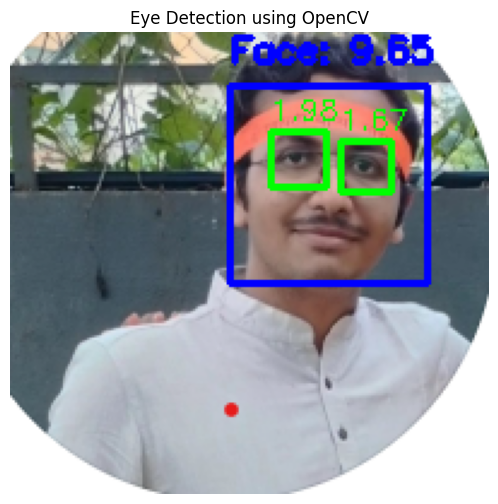

In [107]:
# Step 9: Print number of detected eyes
print("Number of eyes detected:", total_eyes)

# Step 10: Display the final image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(image_rgb)
plt.title("Eye Detection using OpenCV")
plt.axis("off")
plt.show()